# Chandra OCR — Benchmark & Evaluation Notebook (Kaggle T4)

**What this notebook does:**
1. Installs and loads `datalab-to/chandra-ocr-2` on the Kaggle T4 GPU (bfloat16)
2. Benchmarks Chandra on the **RIMES** dataset (Handwritten2Text)
3. Tests Chandra on the **Franz Fanon** medical dataset and evaluates
4. Applies the full **OCR post-processing pipeline** (cleaning) to both datasets
5. Re-evaluates after cleaning so you can compare raw vs cleaned metrics

**Setup:** Settings → Accelerator → **GPU T4 x2**

**Datasets expected on Kaggle input:**
- RIMES: `Handwritten2Text Training Dataset/{Images,Transcriptions}`
- Franz Fanon: `franz-fanon-files-v*/data/{2016,2021}/{images,transcriptions}`
- Dictionaries: `some-alz-fine/{abreviations,medications,terms,tests}.txt`


## Step 0 — Install Requirements

In [1]:
# ── Install Chandra OCR (T4 GPU) ─────────────────────────────────────────────
# T4 (sm_75) is fully supported by the latest torch + transformers — no version
# pinning or source builds needed.
!pip install -q -U chandra-ocr[hf]
!pip install -q python-Levenshtein jiwer pyspellchecker tqdm

import torch
print(f"CUDA available : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU            : {torch.cuda.get_device_name(0)}")
    print(f"VRAM           : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
    cap = torch.cuda.get_device_capability(0)
    print(f"Compute cap.   : sm_{cap[0]}{cap[1]}")
print(f"PyTorch        : {torch.__version__}")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.4/68.4 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.9/109.9 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 55.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 100.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 110.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.


## Step 1 — Configuration (edit paths here)

In [2]:
import os

# ── Dataset paths ─────────────────────────────────────────────────────────────
RIMES_IMAGES_PATH = "/kaggle/input/datasets/chaimaourgani/handwritten2text-training-dataset/Handwritten2Text Training Dataset/Images"
RIMES_TEXTS_PATH  = "/kaggle/input/datasets/chaimaourgani/handwritten2text-training-dataset/Handwritten2Text Training Dataset/Transcriptions"

FFF_IMAGES_DIRS = [
    "/kaggle/input/datasets/baraafzlalagui/franz-fanon-files-v2/data/2021/images",
    "/kaggle/input/datasets/baraafzlalagui/franz-fanon-files-v2/data/2016/images",
]
FFF_TEXTS_DIRS = [
    "/kaggle/input/datasets/baraafzlalagui/franz-fanon-files-v2/data/2021/transcriptions",
    "/kaggle/input/datasets/baraafzlalagui/franz-fanon-files-v2/data/2016/transcriptions",
]

# ── Dictionary paths ──────────────────────────────────────────────────────────
DICT_DIR         = "/kaggle/input/datasets/baraafzlalagui/some-alz-fine"
ABBREV_PATH      = os.path.join(DICT_DIR, "abreviations.txt")
MEDICATIONS_PATH = os.path.join(DICT_DIR, "medications.txt")
TERMS_PATH       = os.path.join(DICT_DIR, "terms.txt")
TESTS_PATH       = os.path.join(DICT_DIR, "tests.txt")

# ── Evaluation limits (set None to run everything) ────────────────────────────
MAX_RIMES_IMAGES = 350    # RIMES has ~6 k images; 200 gives a fast representative benchmark
MAX_FFF_IMAGES   = None   # Franz Fanon is small (~195 docs), run all

# ── Noise tokens to remove from ground-truth labels ──────────────────────────
NOISE_PATTERNS = ['MouMNi', 'Moumni', 'moumni']

# ── Output dir ────────────────────────────────────────────────────────────────
os.makedirs("/kaggle/working/results", exist_ok=True)

print("✓ Configuration set")
for p, label in [(RIMES_IMAGES_PATH, 'RIMES images'), (FFF_IMAGES_DIRS[0], 'FFF 2021')]:
    print(f"  {'✓' if os.path.exists(p) else '✗ MISSING'} {label}: {p}")

✓ Configuration set
  ✓ RIMES images: /kaggle/input/datasets/chaimaourgani/handwritten2text-training-dataset/Handwritten2Text Training Dataset/Images
  ✓ FFF 2021: /kaggle/input/datasets/baraafzlalagui/franz-fanon-files-v2/data/2021/images


## Step 2 — Load Medical Dictionaries

In [3]:
from typing import List, Dict, Tuple

def load_list(file_path: str) -> List[str]:
    items = []
    try:
        with open(file_path, 'r', encoding='utf-8') as f:
            items = [line.strip().lower() for line in f if line.strip()]
        print(f"  ✓ {len(items):>4} items  ← {file_path}")
    except FileNotFoundError:
        print(f"  ⚠ Not found: {file_path}")
    return items

def load_abbreviations(file_path: str) -> Dict[str, str]:
    d = {}
    try:
        with open(file_path, 'r', encoding='utf-8') as f:
            for line in f:
                line = line.strip()
                if not line or ',' not in line:
                    continue
                parts = [p.strip().lower() for p in line.split(',')]
                for variant in parts[1:]:
                    d[variant] = parts[0]
        print(f"  ✓ {len(d):>4} abbreviations ← {file_path}")
    except FileNotFoundError:
        print(f"  ⚠ Not found: {file_path}")
    return d

print("Loading dictionaries...")
abbreviations = load_abbreviations(ABBREV_PATH)
medications   = load_list(MEDICATIONS_PATH)
terms         = load_list(TERMS_PATH)
tests         = load_list(TESTS_PATH)

Loading dictionaries...
  ✓  147 abbreviations ← /kaggle/input/datasets/baraafzlalagui/some-alz-fine/abreviations.txt
  ✓   34 items  ← /kaggle/input/datasets/baraafzlalagui/some-alz-fine/medications.txt
  ✓  138 items  ← /kaggle/input/datasets/baraafzlalagui/some-alz-fine/terms.txt
  ✓    7 items  ← /kaggle/input/datasets/baraafzlalagui/some-alz-fine/tests.txt


## Step 3 — OCR Post-Processing Pipeline

In [4]:
import re
from difflib import SequenceMatcher

# ── 3a. split_mixed_words ─────────────────────────────────────────────────────
def split_mixed_words(text: str) -> str:
    text = re.sub(r'(\d+)([a-zàâäéèêëïîôöœçñ]+)', r'\1 \2', text, flags=re.IGNORECASE)
    text = re.sub(r'([a-zàâäéèêëïîôöœçñ]+)(\d+)', r'\1 \2', text, flags=re.IGNORECASE)
    return text

# ── 3b. normalize_dates ───────────────────────────────────────────────────────
def normalize_dates(text: str) -> str:
    pattern = r'(\d{1,2})\s*[\s/:\-.\']( \d{1,2})\s*[\s/:\-.\']( \d{2,4})'
    pattern = r'(\d{1,2})\s*[/:\-.\'\s](\d{1,2})\s*[/:\-.\'\s](\d{2,4})'
    def _rep(m):
        day, month, year = m.group(1).zfill(2), m.group(2).zfill(2), m.group(3)
        if len(year) == 2:
            year = '20' + year
        return f"{day}/{month}/{year}\n"
    return re.sub(pattern, _rep, text)

# ── 3c. replace_abbreviations ─────────────────────────────────────────────────
def replace_abbreviations(text: str, abbrev_dict: Dict[str, str]) -> Tuple[str, set]:
    words = text.split()
    result, corrected_indices = [], set()
    for i, word in enumerate(words):
        word_clean = re.sub(r"[^\w'/]", '', word.lower())
        if word_clean in abbrev_dict:
            result.append(abbrev_dict[word_clean])
            corrected_indices.add(i)
        else:
            result.append(word)
    return ' '.join(result), corrected_indices

# ── 3d. fuzzy matching ────────────────────────────────────────────────────────
def find_closest_match(word: str, reference_list: List[str], threshold: float = 0.75) -> Tuple[str, bool]:
    word_lower = word.lower()
    if word_lower in reference_list:
        return word_lower, True
    best_match, best_ratio = None, threshold
    for ref in reference_list:
        ratio = SequenceMatcher(None, word_lower, ref).ratio()
        if ratio > best_ratio:
            best_ratio, best_match = ratio, ref
    return (best_match, True) if best_match else (word, False)

def apply_fuzzy_matching(text: str, medications: List[str], terms: List[str], tests: List[str]) -> Tuple[str, set]:
    words = text.split()
    result, corrected_indices = [], set()
    for i, word in enumerate(words):
        m, ok = find_closest_match(word, medications, 0.75)
        if ok: result.append(m); corrected_indices.add(i); continue
        m, ok = find_closest_match(word, terms, 0.75)
        if ok: result.append(m); corrected_indices.add(i); continue
        m, ok = find_closest_match(word, tests, 0.75)
        if ok: result.append(m); corrected_indices.add(i); continue
        result.append(word)
    return ' '.join(result), corrected_indices

# ── 3e. correct_french_spelling ───────────────────────────────────────────────
def correct_french_spelling(text: str, skip_indices: set = None,
                             reference_lists: List[List[str]] = None) -> str:
    if skip_indices is None:
        skip_indices = set()
    if reference_lists is None:
        reference_lists = []
    reference_words = {w.lower() for lst in reference_lists for w in lst}
    try:
        from spellchecker import SpellChecker
        spell = SpellChecker(language='fr')
        words = text.split()
        corrected = []
        for i, word in enumerate(words):
            if i in skip_indices:
                corrected.append(word); continue
            word_lower = word.lower()
            word_clean = re.sub(r'[^\w]', '', word_lower)
            if word_clean in reference_words:
                corrected.append(word); continue
            if not re.search(r'[a-zàâäéèêëïîôöœçñ]', word, re.IGNORECASE):
                corrected.append(word); continue
            if word_clean not in spell:
                closest = spell.correction(word_clean)
                corrected.append(closest if closest else word)
            else:
                corrected.append(word)
        return ' '.join(corrected)
    except ImportError:
        return text

# ── 3f. noise / clean helpers ─────────────────────────────────────────────────
def clean_text(text: str) -> str:
    return re.sub(r'\s+', ' ', text).strip()

def remove_noise(text: str, noise_patterns: List[str]) -> str:
    for pat in noise_patterns:
        try:
            text = re.sub(pat, '', text, flags=re.IGNORECASE)
        except re.error:
            text = text.replace(pat, '')
    return re.sub(r'\s+', ' ', text).strip()

# ── 3g. Main entry point: postprocess_plain_text ─────────────────────────────
def postprocess_plain_text(raw_text: str) -> str:
    """
    Apply full cleaning pipeline to a plain string (Chandra markdown output).
    Mirrors the pipeline from OCR_postprocessing__4_.ipynb.
    """
    text = split_mixed_words(raw_text)
    text = normalize_dates(text)
    text, abbrev_idx  = replace_abbreviations(text, abbreviations)
    text, fuzzy_idx   = apply_fuzzy_matching(text, medications, terms, tests)
    all_corrected     = abbrev_idx | fuzzy_idx
    text = correct_french_spelling(
        text,
        skip_indices=all_corrected,
        reference_lists=[medications, tests, ['CM', 'TM', 'ro']],
    )
    text = remove_noise(text, NOISE_PATTERNS)
    text = clean_text(text)
    return text

# ── Quick smoke test ──────────────────────────────────────────────────────────
_sample = "ATCDs: HTA evoluant depuis 04 ans, trbls mnésique, 2ampoules donecept"
print("Raw    :", _sample)
print("Cleaned:", postprocess_plain_text(_sample))
print()
print("✓ Cleaning pipeline ready")

Raw    : ATCDs: HTA evoluant depuis 04 ans, trbls mnésique, 2ampoules donecept
Cleaned: accès hypertension artérielle évoluant depuis 04 ans, troubles mnésique 2 ampoule donecept

✓ Cleaning pipeline ready


## Step 4 — Load Chandra OCR Model

In [5]:
import torch
from transformers import AutoModelForImageTextToText, AutoProcessor
from chandra.model.hf import generate_hf
from chandra.model.schema import BatchInputItem
from chandra.output import parse_markdown
from PIL import Image

print("Loading Chandra OCR on GPU (bfloat16)...")

chandra_model = AutoModelForImageTextToText.from_pretrained(
    "datalab-to/chandra-ocr-2",
    dtype=torch.bfloat16,
    device_map="auto",
)
chandra_model.eval()
chandra_model.processor = AutoProcessor.from_pretrained("datalab-to/chandra-ocr-2")
chandra_model.processor.tokenizer.padding_side = "left"

print("✓ Chandra OCR loaded")
print(f"  VRAM used: {torch.cuda.memory_allocated()/1e9:.2f} GB")


Loading Chandra OCR on GPU (bfloat16)...


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/10.6G [00:00<?, ?B/s]

[transformers] The fast path is not available because one of the required library is not installed. Falling back to torch implementation. To install follow https://github.com/fla-org/flash-linear-attention#installation and https://github.com/Dao-AILab/causal-conv1d


Loading weights:   0%|          | 0/724 [00:00<?, ?it/s]

...

preprocessor_config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/20.0M [00:00<?, ?B/s]

video_preprocessor_config.json:   0%|          | 0.00/614 [00:00<?, ?B/s]

✓ Chandra OCR loaded
  VRAM used: 4.41 GB


## Step 5 — OCR Inference Helper

In [6]:
import re

# Chandra's vision encoder cost scales with image resolution. The Franz Fanon
# scans are huge (causing 35+ GiB allocation attempts -> OOM on a 16GB T4),
# while RIMES crops are small and worked fine. We resize any image whose
# longest side exceeds MAX_IMAGE_DIM before passing it to the model.
# 1536 is a generous size that preserves handwriting detail while keeping
# memory bounded.
MAX_IMAGE_DIM = 1536

def _resize_for_chandra(img: Image.Image, max_dim: int = MAX_IMAGE_DIM) -> Image.Image:
    w, h = img.size
    longest = max(w, h)
    if longest <= max_dim:
        return img
    scale = max_dim / longest
    new_size = (max(1, int(w * scale)), max(1, int(h * scale)))
    return img.resize(new_size, Image.LANCZOS)

def run_chandra_ocr(image_path: str) -> str:
    """
    Run Chandra OCR on a single image and return plain text
    (markdown headers/bullets stripped). Images are resized to
    MAX_IMAGE_DIM on the longest side to avoid CUDA OOM on large scans.
    """
    try:
        img = Image.open(image_path).convert("RGB")
        img = _resize_for_chandra(img)
        batch = [BatchInputItem(image=img, prompt_type="ocr_layout")]
        result   = generate_hf(batch, chandra_model)[0]
        markdown = parse_markdown(result.raw)
        lines = []
        for line in markdown.splitlines():
            line = re.sub(r'^#+\s*', '', line.strip())
            line = re.sub(r'^[-*•]\s*', '', line)
            if line:
                lines.append(line)
        return ' '.join(lines)
    except torch.cuda.OutOfMemoryError as e:
        # If still OOM (e.g. unusually dense page), retry once at half resolution
        # before giving up, and always clear the cache afterwards.
        torch.cuda.empty_cache()
        try:
            img = Image.open(image_path).convert("RGB")
            img = _resize_for_chandra(img, max_dim=MAX_IMAGE_DIM // 2)
            batch = [BatchInputItem(image=img, prompt_type="ocr_layout")]
            result   = generate_hf(batch, chandra_model)[0]
            markdown = parse_markdown(result.raw)
            lines = []
            for line in markdown.splitlines():
                line = re.sub(r'^#+\s*', '', line.strip())
                line = re.sub(r'^[-*•]\s*', '', line)
                if line:
                    lines.append(line)
            return ' '.join(lines)
        except Exception as e2:
            torch.cuda.empty_cache()
            print(f"  ⚠ Chandra OOM (even at half-res) on {image_path}: {e2}")
            return ""
    except Exception as e:
        print(f"  ⚠ Chandra error on {image_path}: {e}")
        return ""

print("✓ run_chandra_ocr() defined (with image resizing + OOM retry)")


✓ run_chandra_ocr() defined (with image resizing + OOM retry)


## Step 6 — Evaluation Metrics

In [7]:
import numpy as np
import Levenshtein

def calculate_character_accuracy(gt: str, pred: str) -> float:
    if not gt and not pred:
        return 1.0
    if not gt:
        return 0.0
    dist     = Levenshtein.distance(gt, pred)
    max_len  = max(len(gt), len(pred))
    return 1 - (dist / max_len)

def calculate_word_accuracy(gt: str, pred: str) -> float:
    gt_words   = gt.split()
    pred_words = pred.split()
    if not gt_words and not pred_words:
        return 1.0
    if not gt_words:
        return 0.0
    pred_copy = pred_words.copy()
    matches = 0
    for w in gt_words:
        if w in pred_copy:
            matches += 1
            pred_copy.remove(w)
    return matches / len(gt_words)

def calculate_cer(all_gt: List[str], all_pred: List[str]) -> float:
    """Character Error Rate (CER) = total Levenshtein / total GT chars."""
    total_dist, total_chars = 0, 0
    for gt, pred in zip(all_gt, all_pred):
        total_dist  += Levenshtein.distance(gt, pred)
        total_chars += len(gt)
    return total_dist / total_chars if total_chars > 0 else 0.0

def calculate_wer(all_gt: List[str], all_pred: List[str]) -> float:
    """Word Error Rate (WER) at word-edit-distance level."""
    total_ops, total_words = 0, 0
    for gt, pred in zip(all_gt, all_pred):
        total_ops   += Levenshtein.distance(gt.split(), pred.split())
        total_words += len(gt.split())
    return total_ops / total_words if total_words > 0 else 0.0

def print_metrics(label: str,
                  all_gt: List[str], all_pred: List[str],
                  char_accs: List[float], word_accs: List[float]) -> dict:
    exact = sum(1 for g, p in zip(all_gt, all_pred) if g == p)
    metrics = {
        'avg_char_accuracy'  : float(np.mean(char_accs)),
        'avg_word_accuracy'  : float(np.mean(word_accs)),
        'cer'                : calculate_cer(all_gt, all_pred),
        'wer'                : calculate_wer(all_gt, all_pred),
        'exact_match'        : exact / len(all_gt) if all_gt else 0.0,
        'n_samples'          : len(all_gt),
    }
    print(f"\n{'='*60}")
    print(f"  {label}")
    print(f"{'='*60}")
    print(f"  Samples              : {metrics['n_samples']}")
    print(f"  Avg Char Accuracy    : {metrics['avg_char_accuracy']:.2%}")
    print(f"  Avg Word Accuracy    : {metrics['avg_word_accuracy']:.2%}")
    print(f"  CER (lower=better)   : {metrics['cer']:.2%}")
    print(f"  WER (lower=better)   : {metrics['wer']:.2%}")
    print(f"  Exact Match          : {metrics['exact_match']:.2%}")
    print()
    print("  --- Sample comparisons (first 3) ---")
    for i in range(min(3, len(all_gt))):
        print(f"  [{i+1}] GT  : {all_gt[i][:120]}")
        print(f"      PRED: {all_pred[i][:120]}")
        print(f"      CharAcc={char_accs[i]:.1%}  WordAcc={word_accs[i]:.1%}")
        print()
    return metrics

print("✓ Evaluation metrics defined")

✓ Evaluation metrics defined


## Step 7 — Ground Truth Parsers

Two formats are in use:
- **RIMES** (`handwritten2text`): plain text `.txt` file, one transcription per file
- **Franz Fanon**: `Text: … / Points: …` pair format in `*_label.txt`

In [8]:
import json

# ── RIMES ground truth ────────────────────────────────────────────────────────
def read_rimes_gt(txt_path: str) -> str:
    """
    RIMES transcription files contain the raw text directly
    (one transcription per file, plain UTF-8).
    """
    try:
        with open(txt_path, 'r', encoding='utf-8') as f:
            return f.read().strip()
    except Exception:
        return ""

# ── Franz Fanon ground truth ─────────────────────────────────────────────────
def parse_fff_gt_file(txt_path: str) -> str:
    """
    Franz Fanon label format:
        Text: <text>
        Points: [[x1,y1],[x2,y2],...]
    Returns text segments sorted by y then x, joined as one string.
    """
    if not os.path.exists(txt_path):
        return ""
    with open(txt_path, 'r', encoding='utf-8') as f:
        content = f.read().strip()
    if not content:
        return ""

    segments = []
    lines = content.split('\n')
    i = 0
    while i < len(lines):
        if lines[i].startswith('Text:'):
            text = lines[i].replace('Text:', '').strip()
            if i + 1 < len(lines) and lines[i+1].startswith('Points:'):
                pts_str = lines[i+1].replace('Points:', '').strip()
                try:
                    pts = json.loads(pts_str)
                    if pts:
                        y, x = pts[0][1], pts[0][0]
                        segments.append({'text': text, 'y': y, 'x': x})
                except Exception:
                    pass
                i += 2
                continue
        i += 1

    if not segments:
        return ""

    # Sort reading order (top-to-bottom, left-to-right)
    segments.sort(key=lambda s: (s['y'], s['x']))
    return ' '.join(s['text'] for s in segments)

print("✓ GT parsers defined")

✓ GT parsers defined


## Step 8 — Benchmark on RIMES Dataset

In [9]:
from tqdm import tqdm

def benchmark_chandra_rimes(
    images_path: str,
    texts_path: str,
    max_images: int = None,
) -> dict:
    """
    Run Chandra OCR on RIMES and collect raw + cleaned metrics.
    Returns a dict of {raw: metrics_dict, cleaned: metrics_dict}.
    """
    image_files = sorted([
        f for f in os.listdir(images_path)
        if f.lower().endswith(('.png', '.jpg', '.jpeg'))
    ])
    if max_images:
        image_files = image_files[:max_images]

    print(f"\nRunning Chandra OCR on RIMES — {len(image_files)} images")

    all_gt, all_raw, all_cleaned = [], [], []
    raw_char_acc, raw_word_acc   = [], []
    cln_char_acc, cln_word_acc   = [], []

    for img_file in tqdm(image_files, desc="RIMES"):
        # Ground truth: same basename, .txt extension
        base     = os.path.splitext(img_file)[0]
        txt_path = os.path.join(texts_path, base + '.txt')
        img_path = os.path.join(images_path, img_file)

        gt = read_rimes_gt(txt_path)
        if not gt:
            continue

        # Run Chandra
        raw_pred     = run_chandra_ocr(img_path)
        cleaned_pred = postprocess_plain_text(raw_pred)

        all_gt.append(gt)
        all_raw.append(raw_pred)
        all_cleaned.append(cleaned_pred)

        raw_char_acc.append(calculate_character_accuracy(gt, raw_pred))
        raw_word_acc.append(calculate_word_accuracy(gt, raw_pred))
        cln_char_acc.append(calculate_character_accuracy(gt, cleaned_pred))
        cln_word_acc.append(calculate_word_accuracy(gt, cleaned_pred))

    raw_metrics = print_metrics(
        "RIMES — Chandra RAW",
        all_gt, all_raw, raw_char_acc, raw_word_acc
    )
    cln_metrics = print_metrics(
        "RIMES — Chandra + OCR Pipeline (Cleaned)",
        all_gt, all_cleaned, cln_char_acc, cln_word_acc
    )

    return {"raw": raw_metrics, "cleaned": cln_metrics}


# rimes_results = benchmark_chandra_rimes(
#     images_path=RIMES_IMAGES_PATH,
#     texts_path=RIMES_TEXTS_PATH,
#     max_images=MAX_RIMES_IMAGES,
# )

## Step 9 — Test on Franz Fanon Dataset

In [10]:
def benchmark_chandra_fff(
    images_dirs: List[str],
    texts_dirs: List[str],
    max_images: int = None,
) -> dict:
    """
    Run Chandra OCR on the Franz Fanon dataset.
    Label files are *_label.txt using the Text:/Points: format.
    Returns a dict of {raw: metrics_dict, cleaned: metrics_dict}.
    """
    # Collect all (image_path, label_path) pairs
    pairs = []
    for img_dir, txt_dir in zip(images_dirs, texts_dirs):
        if not os.path.exists(img_dir):
            print(f"  ⚠ Missing: {img_dir}")
            continue
        for img_file in sorted(os.listdir(img_dir)):
            if not img_file.lower().endswith(('.png', '.jpg', '.jpeg')):
                continue
            base      = os.path.splitext(img_file)[0]
            # Franz Fanon label convention: <base>_label.txt
            lbl_path  = os.path.join(txt_dir, base + '_label.txt')
            img_path  = os.path.join(img_dir, img_file)
            if os.path.exists(lbl_path):
                pairs.append((img_path, lbl_path))

    if max_images:
        pairs = pairs[:max_images]

    print(f"\nRunning Chandra OCR on Franz Fanon — {len(pairs)} documents")

    all_gt, all_raw, all_cleaned = [], [], []
    raw_char_acc, raw_word_acc   = [], []
    cln_char_acc, cln_word_acc   = [], []

    for img_path, lbl_path in tqdm(pairs, desc="FFF"):
        gt = parse_fff_gt_file(lbl_path)
        # Strip known noise tokens from the ground truth itself
        gt = remove_noise(gt, NOISE_PATTERNS)
        if not gt:
            continue

        raw_pred     = run_chandra_ocr(img_path)
        cleaned_pred = postprocess_plain_text(raw_pred)

        all_gt.append(gt)
        all_raw.append(raw_pred)
        all_cleaned.append(cleaned_pred)

        raw_char_acc.append(calculate_character_accuracy(gt, raw_pred))
        raw_word_acc.append(calculate_word_accuracy(gt, raw_pred))
        cln_char_acc.append(calculate_character_accuracy(gt, cleaned_pred))
        cln_word_acc.append(calculate_word_accuracy(gt, cleaned_pred))

        # Progress snapshot every 20 docs
        n = len(all_gt)
        if n % 20 == 0:
            print(f"  [{n}] raw CER={calculate_cer(all_gt, all_raw):.2%}  "
                  f"cleaned CER={calculate_cer(all_gt, all_cleaned):.2%}")

    raw_metrics = print_metrics(
        "Franz Fanon — Chandra RAW",
        all_gt, all_raw, raw_char_acc, raw_word_acc
    )
    cln_metrics = print_metrics(
        "Franz Fanon — Chandra + OCR Pipeline (Cleaned)",
        all_gt, all_cleaned, cln_char_acc, cln_word_acc
    )

    return {
        "raw"    : raw_metrics,
        "cleaned": cln_metrics,
        "samples": [
            {"gt": g, "raw": r, "cleaned": c}
            for g, r, c in zip(all_gt, all_raw, all_cleaned)
        ]
    }


fff_results = benchmark_chandra_fff(
    images_dirs=FFF_IMAGES_DIRS,
    texts_dirs=FFF_TEXTS_DIRS,
    max_images=MAX_FFF_IMAGES,
)


Running Chandra OCR on Franz Fanon — 195 documents


FFF:   0%|          | 0/195 [00:00<?, ?it/s][transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.
FFF:   1%|          | 1/195 [02:08<6:56:54, 128.94s/it][transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.
FFF:   1%|          | 2/195 [04:17<6:54:20, 128.81s/it][transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.
FFF:   2%|▏         | 3/195 [06:11<6:30:51, 122.14s/it][transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.

  [20] raw CER=145.08%  cleaned CER=193.15%


[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.
FFF:  11%|█         | 21/195 [1:00:43<7:23:17, 152.86s/it][transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.
FFF:  11%|█▏        | 22/195 [1:03:04<7:10:09, 149.19s/it][transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.
FFF:  12%|█▏        | 23/195 [1:05:37<7:11:03, 150.37s/it][transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.
FFF:  12%|█▏        | 24/195 [1:07

  [40] raw CER=86.56%  cleaned CER=115.53%


...

  [160] raw CER=71.71%  cleaned CER=78.22%


[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.
FFF:  83%|████████▎ | 161/195 [5:58:25<1:02:05, 109.57s/it][transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.
FFF:  83%|████████▎ | 162/195 [6:00:21<1:01:21, 111.56s/it][transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.
FFF:  84%|████████▎ | 163/195 [6:01:36<53:38, 100.58s/it]  [transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.
FFF:  84%|████████▍ | 164/195 [

  [180] raw CER=68.11%  cleaned CER=74.97%


[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.
FFF:  93%|█████████▎| 181/195 [6:36:14<25:04, 107.47s/it][transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.
FFF:  93%|█████████▎| 182/195 [6:38:25<24:49, 114.57s/it][transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.
FFF:  94%|█████████▍| 183/195 [6:39:47<20:59, 104.97s/it][transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.
FFF:  94%|█████████▍| 184/195 [6:41:4


  Franz Fanon — Chandra RAW
  Samples              : 195
  Avg Char Accuracy    : 64.86%
  Avg Word Accuracy    : 45.99%
  CER (lower=better)   : 77.99%
  WER (lower=better)   : 93.33%
  Exact Match          : 0.00%

  --- Sample comparisons (first 3) ---
  [1] GT  : patiente agée de 37ans mariée,mère Le 26/12/2021 de 4 enfants vivants, Née à Medea et demeurant psychlogue à Blida (Oule
      PRED: le 26/12/2021 psychologue Moumni patiente âgée de 37 ans, maride, mère de 4 enfants vivants, Née à Medea et demeurant à 
      CharAcc=69.5%  WordAcc=70.2%

  [2] GT  : le 07 12 21 ### va bien Depuis 03ans, troubles de la mémoire, surtout des faits recents pas troubles du comportements ##
      PRED: le 07/12/21 ATUA-F: RAS of l'hyperémie de l'orni. Depuis 08 ans, l'embry se le mène, malentendu au fait recent, sur l'em
      CharAcc=64.3%  WordAcc=54.1%

  [3] GT  : aggravation des tbls mnesiques depuis 3 ans mémoire à long terme est preservée. - la fois par jour - elle fait et refait
      

## Step 10 — Final Summary & Save Results

In [11]:
import json

summary = {
    # "RIMES": {
    #     "raw"    : rimes_results["raw"],
    #     "cleaned": rimes_results["cleaned"],
    # },
    "FranzFanon": {
        "raw"    : fff_results["raw"],
        "cleaned": fff_results["cleaned"],
    },
}

print("\n" + "="*70)
print("  CHANDRA OCR — COMPLETE BENCHMARK SUMMARY")
print("="*70)
header = f"{'Dataset':<25} {'Stage':<10} {'CER':>8} {'WER':>8} {'CharAcc':>9} {'WordAcc':>9}"
print(header)
print("-"*70)
for dataset, stages in summary.items():
    for stage, m in stages.items():
        print(f"  {dataset:<23} {stage:<10} "
              f"{m['cer']:>7.2%} {m['wer']:>7.2%} "
              f"{m['avg_char_accuracy']:>8.2%} {m['avg_word_accuracy']:>8.2%}")
print("="*70)

# Save full summary (excluding per-sample data for compactness)
out_path = "/kaggle/working/results/chandra_benchmark_summary.json"
with open(out_path, 'w', encoding='utf-8') as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)
print(f"\n✓ Summary saved to {out_path}")

# Optionally save FFF per-sample predictions for deeper error analysis
samples_path = "/kaggle/working/results/fff_chandra_predictions.jsonl"
with open(samples_path, 'w', encoding='utf-8') as f:
    for sample in fff_results.get("samples", []):
        f.write(json.dumps(sample, ensure_ascii=False) + '\n')
print(f"✓ FFF per-sample predictions saved to {samples_path}")


  CHANDRA OCR — COMPLETE BENCHMARK SUMMARY
Dataset                   Stage           CER      WER   CharAcc   WordAcc
----------------------------------------------------------------------
  FranzFanon              raw         77.99%  93.33%   64.86%   45.99%
  FranzFanon              cleaned     85.45% 111.95%   56.57%   38.48%

✓ Summary saved to /kaggle/working/results/chandra_benchmark_summary.json
✓ FFF per-sample predictions saved to /kaggle/working/results/fff_chandra_predictions.jsonl


## Step 11 — Optional: Per-Document Error Analysis (Franz Fanon)

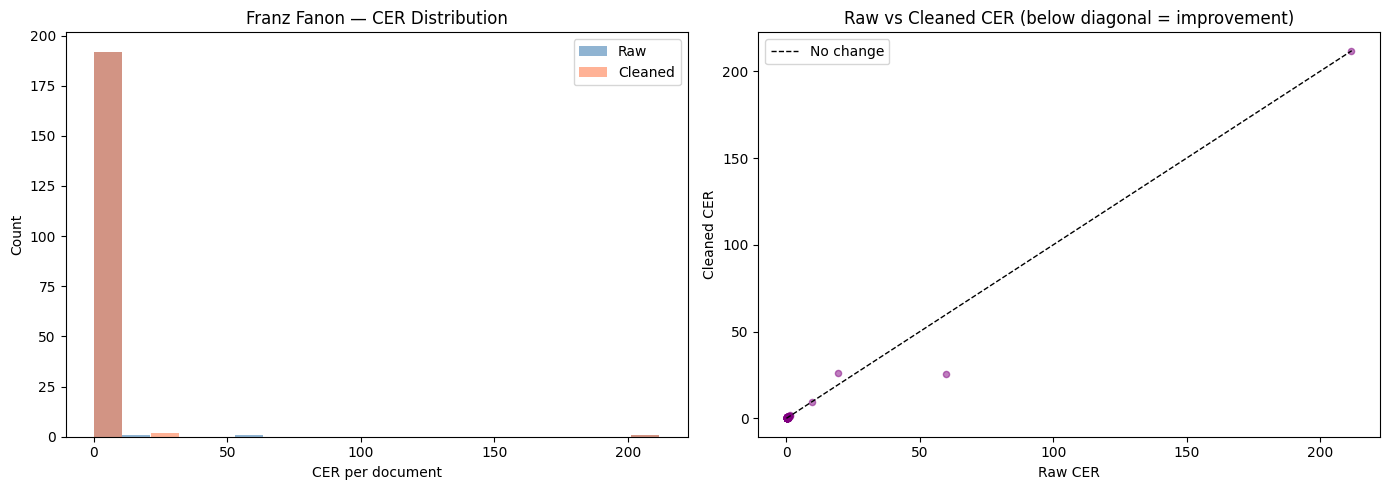


Documents where cleaning helped : 5 / 195
Median CER improvement           : -0.093
Mean  CER improvement            : 0.033


In [12]:
import pandas as pd
import matplotlib.pyplot as plt

samples = fff_results.get("samples", [])
if samples:
    rows = []
    for s in samples:
        raw_cer = Levenshtein.distance(s['gt'], s['raw']) / max(len(s['gt']), 1)
        cln_cer = Levenshtein.distance(s['gt'], s['cleaned']) / max(len(s['gt']), 1)
        rows.append({
            'raw_cer'    : raw_cer,
            'cleaned_cer': cln_cer,
            'improvement': raw_cer - cln_cer,
            'gt_len'     : len(s['gt']),
        })

    df = pd.DataFrame(rows)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # CER distribution before vs after cleaning
    axes[0].hist(df['raw_cer'],     bins=20, alpha=0.6, label='Raw',     color='steelblue')
    axes[0].hist(df['cleaned_cer'], bins=20, alpha=0.6, label='Cleaned', color='coral')
    axes[0].set_xlabel('CER per document')
    axes[0].set_ylabel('Count')
    axes[0].set_title('Franz Fanon — CER Distribution')
    axes[0].legend()

    # CER improvement scatter
    axes[1].scatter(df['raw_cer'], df['cleaned_cer'], alpha=0.5, s=20, color='purple')
    lim = max(df['raw_cer'].max(), df['cleaned_cer'].max()) + 0.05
    axes[1].plot([0, lim], [0, lim], 'k--', lw=1, label='No change')
    axes[1].set_xlabel('Raw CER')
    axes[1].set_ylabel('Cleaned CER')
    axes[1].set_title('Raw vs Cleaned CER (below diagonal = improvement)')
    axes[1].legend()

    plt.tight_layout()
    plt.savefig("/kaggle/working/results/fff_cer_analysis.png", dpi=150)
    plt.show()

    print(f"\nDocuments where cleaning helped : {(df['improvement'] > 0).sum()} / {len(df)}")
    print(f"Median CER improvement           : {df['improvement'].median():.3f}")
    print(f"Mean  CER improvement            : {df['improvement'].mean():.3f}")
else:
    print("No FFF samples found — run Step 9 first.")